# 30 — How the complete FRTB Internal Models Approach calculation works

Connect the existing Standardised Approach to the Internal Models Approach using the same trades, prices and risk factors.

The Fundamental Review of the Trading Book (FRTB) uses desk-level model eligibility. Modellable Risk Factors enter Expected Shortfall; Non-Modellable Risk Factors receive a separate stress measure; default risk is simulated independently. Profit and Loss Attribution and backtesting determine which desks may use the model.

This step uses: The shared 48-trade book, the SA run, the IMA factor inventory and the combined capital summary.

It produces: A complete map from trade to final market-risk capital and Market RWA.

> Basel norm applied: MAR30–MAR33 require desk approval, RFET, ES, NMRF treatment, IMA DRC, PLA, backtesting and SA fallback.

$$K_{Market}=C_A+DRC+PLA\ surcharge+C_U,\qquad RWA_{Market}=12.5K_{Market}$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260901T122303Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


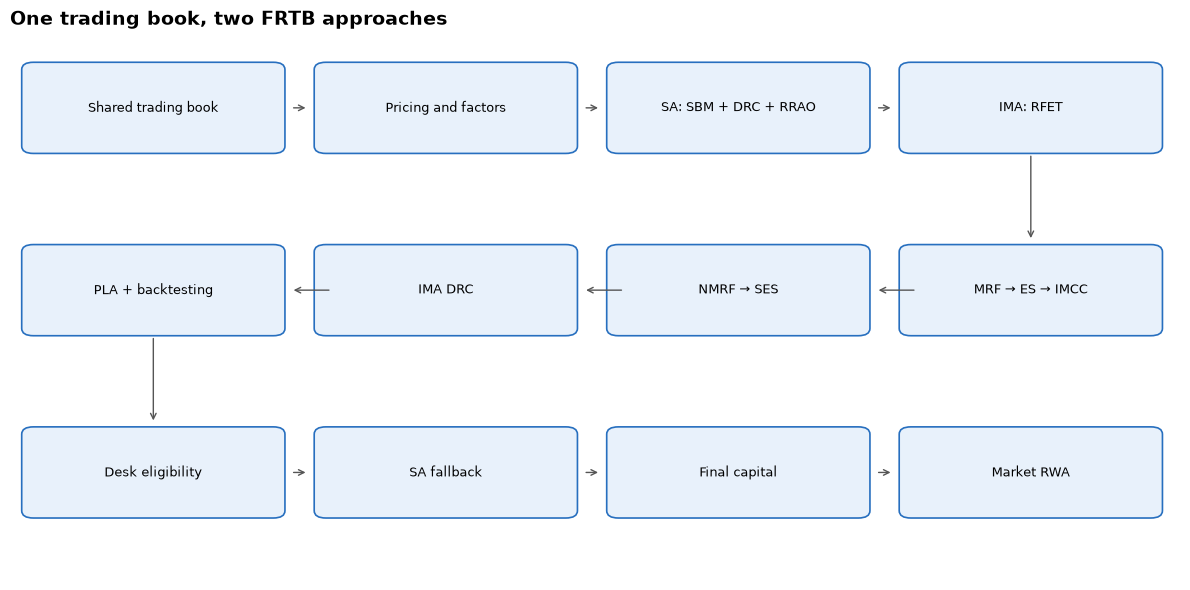

In [2]:
draw_flow(['Shared trading book','Pricing and factors','SA: SBM + DRC + RRAO','IMA: RFET','MRF → ES → IMCC','NMRF → SES','IMA DRC','PLA + backtesting','Desk eligibility','SA fallback','Final capital','Market RWA'], 'One trading book, two FRTB approaches', wrap_after=4)

The flow diagram shows the order of the complete calculation. SA and IMA begin with the same trades and risk factors. The IMA branch then separates modellable factors, non-modellable factors and default risk before desk testing decides whether IMA or SA fallback is used.

,INR crore
Full-book SA benchmark,109.4964
Eligible-desk IMA before surcharge,88.7167
PLA amber surcharge,0.0000
SA fallback,0.0800
Final market-risk capital,88.7967


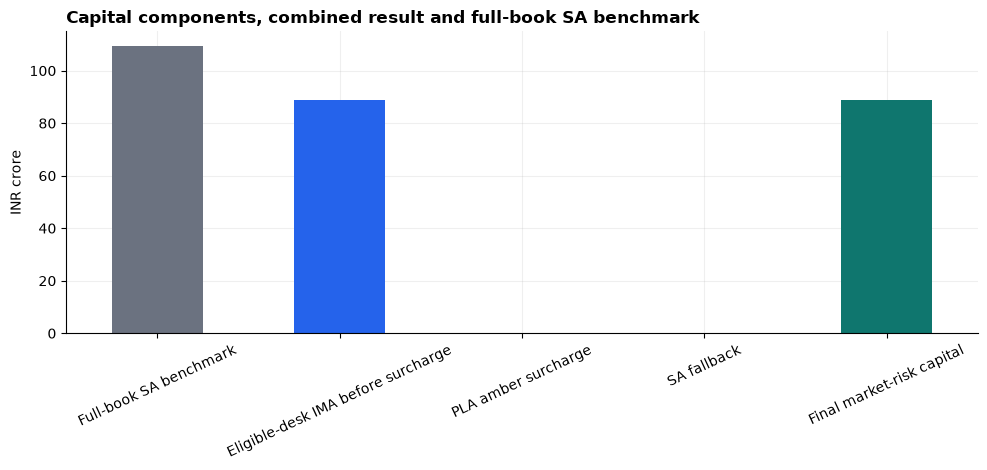

Final capital INR 88.80 crore × 12.5 = Market RWA INR 1,109.96 crore


In [3]:
capital=pd.Series({'Full-book SA benchmark':SUMMARY['full_book_sa_capital_inr'],'Eligible-desk IMA before surcharge':SUMMARY['ima_eligible_capital_before_surcharge_inr'],'PLA amber surcharge':SUMMARY['pla_amber_surcharge_inr'],'SA fallback':SUMMARY['sa_fallback_capital_inr'],'Final market-risk capital':SUMMARY['final_frtb_market_risk_capital_inr']})
display((capital/INR_CRORE).rename('INR crore').to_frame())
ax=(capital/INR_CRORE).plot(kind='bar',color=['#6B7280','#2563EB','#F59E0B','#DC2626','#0F766E'])
ax.set_ylabel('INR crore'); ax.set_title('Capital components, combined result and full-book SA benchmark',loc='left',weight='bold'); ax.tick_params(axis='x',rotation=25); plt.tight_layout(); plt.show()
print(f"Final capital {money(SUMMARY['final_frtb_market_risk_capital_inr'])} × 12.5 = Market RWA {money(SUMMARY['market_rwa_inr'])}")

The bars compare the full-book SA benchmark with the amounts used to assemble the combined result. Eligible-desk IMA, any amber-desk surcharge and SA fallback are additive components. The final-capital bar is their total, so neither the SA benchmark nor the final-capital bar should be added to the three component bars.